In this part i will be combining all days of attacks in a single dataset. I want to shift my focus from the idea of "Can my code identify a specific attack?" to something more complex that is "Can my code act as an universal alarm for any abnormal behavior?". 

In [1]:
#Imports
import pandas as pd
import numpy as np
import glob #The glob module finds all the pathnames matching a specified pattern according to the rules used by the Unix shell. (https://www.w3schools.com/python/ref_module_glob.asp)
import matplotlib.pyplot as plt

In [2]:
#Combining all CSVs files
print("Loading and combining all CSV files")
file_paths = glob.glob("MachineLearningCVE/*.csv")
print(f"Found {len(file_paths)} files. Stitching them together... (This may take a minute or two)")

df_list = [pd.read_csv(file,low_memory=False) for file in file_paths]
df = pd.concat(df_list, ignore_index=True)



Loading and combining all CSV files
Found 8 files. Stitching them together... (This may take a minute or two)


In [3]:
#Stripping and replacing internal spaces with underscores
df.columns = df.columns.str.strip().str.replace(' ', '_')
print(df.columns)

Index(['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets',
       'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets',
       'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max',
       'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean',
       'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max',
       'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean',
       'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s',
       'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min',
       'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max',
       'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std',
       'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Bwd_PSH_Flags',
       'Fwd_URG_Flags', 'Bwd_URG_Flags', 'Fwd_Header_Length',
       'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s',
       'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean',
       'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count',
       'SYN_Flag_Co

In [4]:
#Looking at the Labels before combining all for Binary Classification
#And changing the weird sign of Web Attacks
df['Label'] = df['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - SQL Injection'
})

original_label = df['Label'].value_counts()
df['Label'].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - SQL Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [5]:
#Converting to Binary Labels
#df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
#df['Label'].value_counts()

In [6]:
#Information about the data
print(f"\nShape: {df.shape[0]} rows and {df.shape[1]} columns")

print("\n First 5 rows: ")
display(df.head())

print("\n Dataset info: Memory and Data Type")
df.info(memory_usage='deep') 


Shape: 2830743 rows and 79 columns

 First 5 rows: 


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,...,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



 Dataset info: Memory and Data Type
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination_Port             int64  
 1   Flow_Duration                int64  
 2   Total_Fwd_Packets            int64  
 3   Total_Backward_Packets       int64  
 4   Total_Length_of_Fwd_Packets  int64  
 5   Total_Length_of_Bwd_Packets  int64  
 6   Fwd_Packet_Length_Max        int64  
 7   Fwd_Packet_Length_Min        int64  
 8   Fwd_Packet_Length_Mean       float64
 9   Fwd_Packet_Length_Std        float64
 10  Bwd_Packet_Length_Max        int64  
 11  Bwd_Packet_Length_Min        int64  
 12  Bwd_Packet_Length_Mean       float64
 13  Bwd_Packet_Length_Std        float64
 14  Flow_Bytes/s                 float64
 15  Flow_Packets/s               float64
 16  Flow_IAT_Mean                float64
 17  Flow_IAT_Std                 float64
 18  Flow_IAT_Max    

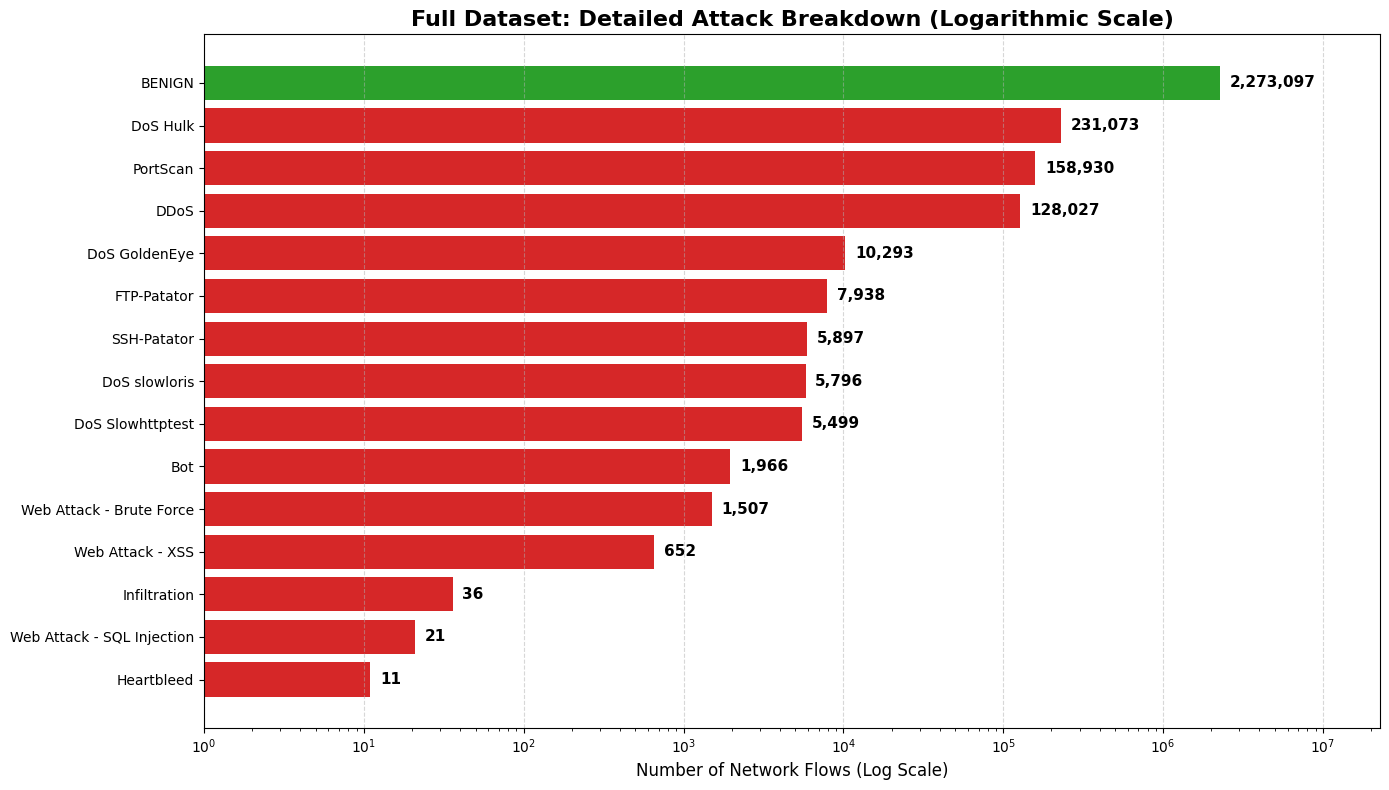

In [ ]:
#Data Visualization 
plt.figure(figsize=(14, 8))

#Sorting values ascending 
counts_sorted = original_label.sort_values(ascending=True)

#Creating the lines and using green for normal trafic and red for the rest
colors = ['#2ca02c' if label == 'BENIGN' else '#d62728' for label in counts_sorted.index]
bars = plt.barh(counts_sorted.index, counts_sorted.values, color=colors)

#Adding the number to each bar
for bar in bars:
    xval = bar.get_width()
    plt.text(xval * 1.15, bar.get_y() + bar.get_height()/2, f"{int(xval):,}", 
             va='center', ha='left', fontsize=11, fontweight='bold')

plt.title('Full Dataset: Detailed Attack Breakdown (Logarithmic Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Network Flows (Log Scale)', fontsize=12)

#This helps in making Heartbleed (11) visible next to BENIGN (2.2M) as the diff in numbers is too great
plt.xscale('log') 

#Extends the right margin slightly so the numbers don't get cut off
plt.xlim(1, counts_sorted.max() * 10) 

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

This demonstrates the extreme imbalance that is present in CIC dataset. A logarithmic scale was required for visualization, considering that the occuranges ranges from 2.2m benign flows to only 11 Heartbleed attacks. This is also good in seeing why SMOTE was required in working with the datasets. 

I will now move on to cleaning, training and comparing all the models on the complete dataset. Despite how we have used SMOTE earlier for the other specific CSVs, i will not be doing the same here.
My current hardware disposition has a total of 24 GB of RAM, from which i am already using 13 simply by having my computer on with the dataset active in the code, which leaves me with only 11 free GB of RAM. Even though my laptop has been quite solid until now, the math that happens behind the code when using SMOTE on such a big dataset will eat up a lot more than i have (after tries and crashes).
A small explanation of the SMOTE and dataset:
1. The Dataset: As we saw earlier in df.info, pandas takes up 1.8gb of my RAM just to have the data sitting there.
2. The SMOTE Math (K Nearest Neighbors): SMOTE creates synthetic data, but it doesn't just copy/paste them, it will actually go through a mathematical formula, an algorithm called "K-Nearest Neighbors". t has to look at all 550,000 attack rows, calculate the mathematical distance between them, and draw lines to create new data points. These lines, despite being temporary calculations, will create an invisible matrices on the whole RAM. In theory this step can take up to 6gb
3. Final SMOTE size: Because of the synthetic data there will be ~1.7m fake rows generated to balance this dataset so the training set will achieve a ~4.4m rows. This can also translate to almost 4gb or RAM used 
4. The Model Training: So, with the idea that i do end up passing these almost 4gb dataset into a Random Forest or even a Neural Network, and tell it to used all the cpu cores i have (using the n_jobs=-1), the Scikit-Learn Library copies the dataset for each core. I have only a 4core processor so it might try to duplicate it 4 times. This can take me to 16gb used, which i personally don't have

With the barely there 11gb of free ram i still have, my computer might as well panic and try to use my hard drive as "fake RAM". Which for me resulted into errors and shut downs 

With that out of the way, now i will explain a bit why i don't really even need SMOTE for this part.

In previous experiments (like in the one i had Infiltration), the attacks were so sparse that i clearly needed SMOTE, so it can calculate and create mor that to train my models on. But in this combined dataset, as seen earlier using df.shape(), i have ~2.2m normal traffic and 550.000 attacks, which is an 80/20 split for my data.
As mentioned in the other files, modern tree-based models like XGBoost and Random Forest are incredibly smart, so an 80/20 split is enough of data for them to learn what an attack looks like without needing synthetic data.

Things to try in case i want to push my laptop past its limits again:
1. Reducing the default 64 to 32 bit decimals (which should cut the ram usage in half?)
2. A forced delete of the data that i used so i can empty the ram while being in the process
3. Or i skip the Neural Network which always eats the most out of my stats, and i keep only the xgboost and lightgbm which are focused on ram efficiency too.

In [ ]:
# List of columns that typically cause data leakage or aren't useful for generalizable patterns
columns_to_drop = [
    'Flow_ID', 'Source_IP', 'Source_Port', 'Destination_IP', 
    'Destination_Port', 'Timestamp'
]

# Dropping them only if they exist in the dataframe to avoid errors
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_cols_to_drop:
    df.drop(columns=existing_cols_to_drop, inplace=True)
    print(f"Dropped columns: {existing_cols_to_drop}")

Dropped columns: ['Destination_Port']


In [9]:
#Converting to Binary Labels
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
df['Label'].value_counts()

Label
0    2273097
1     557646
Name: count, dtype: int64

In [10]:
#Imports for cleaing, training and models
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

In [11]:
print("Cleaning the Dataset")
df_clean = df.dropna()
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Data cleaned. Remaining rows: {df_clean.shape[0]:,}")

Cleaning the Dataset
Data cleaned. Remaining rows: 2,827,876


In [12]:
df_clean['Label'].value_counts()

Label
0    2271320
1     556556
Name: count, dtype: int64

In [13]:
#Splitting the data
X = df_clean.drop('Label', axis=1)
y = df_clean['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
#Scaling the dataset 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
#Multi-Model Cycling

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1),

    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    #Lowered max_iter slightly for MLP so it doesn't run for 4 hours (again...)
    "MLP (Neural Net)": MLPClassifier(hidden_layer_sizes=(50,), max_iter=50, random_state=42) 
}

results = []

In [16]:
df['Label'].value_counts()

Label
0    2273097
1     557646
Name: count, dtype: int64

In [17]:
for name, model in models.items():
    print(f" -> Training {name}... Started at: {time.strftime('%H:%M:%S')}")
    start_time = time.time()

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    train_time = time.time() - start_time
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy %": round(acc * 100,4),
        "Recall %": round(recall * 100, 4),
        "F1-score": round(f1, 4),
        "Training Time (s)": round(train_time, 2)
    })
    print(f"    Finished in {round(train_time,2)} seconds.")



 -> Training Decision Tree... Started at: 18:14:09
    Finished in 327.96 seconds.
 -> Training Random Forest... Started at: 18:19:37
    Finished in 222.07 seconds.
 -> Training XGBoost... Started at: 18:23:20
    Finished in 49.97 seconds.
 -> Training LightGBM... Started at: 18:24:10
[LightGBM] [Info] Number of positive: 445245, number of negative: 1817055
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.978089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14348
[LightGBM] [Info] Number of data points in the train set: 2262300, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196811 -> initscore=-1.406348
[LightGBM] [Info] Start training from score -1.406348


c:\Users\Magda\Desktop\AnomalyDetection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    Finished in 46.69 seconds.
 -> Training Logistic Regression... Started at: 18:24:57


c:\Users\Magda\Desktop\AnomalyDetection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


    Finished in 218.49 seconds.
 -> Training MLP (Neural Net)... Started at: 18:28:36


c:\Users\Magda\Desktop\AnomalyDetection\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


    Finished in 1189.17 seconds.


In [18]:
#Sorting by F1-Score because it balances Precision and Recall best for this scenario with all the datasets combined
results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
display(results_df)

,Model,Accuracy %,Recall %,F1-score,Training Time (s)
2,XGBoost,99.9063,99.8599,0.9976,49.97
0,Decision Tree,99.8921,99.8176,0.9973,327.96
3,LightGBM,99.8923,99.8149,0.9973,46.69
1,Random Forest,99.8725,99.7098,0.9968,222.07
5,MLP (Neural Net),98.5701,94.7975,0.9631,1189.17
4,Logistic Regression,93.2623,81.1420,0.8258,218.49
